In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, root_mean_squared_error

import numpy as np

from sqlalchemy import create_engine
import pymysql

In [2]:
def get_evaluation(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    median_ae = median_absolute_error(y_test, y_pred)

    return [mae, mse, rmse, r2, mape, median_ae]

In [3]:
def save_prediction(y_test, y_predict, file_name):
    y_predict_flat = y_predict.flatten()
    y_predict_series = pd.Series(y_predict_flat, name='Predicted')

    y_test.reset_index(drop=True, inplace=True)
    y_predict_series.reset_index(drop=True, inplace=True)

    combined_df = pd.concat([y_test, y_predict_series], axis=1)
    combined_df.to_csv(file_name, index=False)


In [4]:
username = "root"
password = ""
port = 3306
database = "common"

In [5]:
engine = create_engine('mysql+pymysql://%s@localhost:%i/%s' %(username, port, database))

In [6]:
sql = "SELECT * FROM common.histone_count_overlap80"
histone_count_df = pd.read_sql_query(sql, engine)

display(histone_count_df.head())
display(histone_count_df.shape)

,h_chrom,tss_start,tss_end,h_chromStart,h_chromEnd,h_gene,h_test_id,h_gene_id,h_locus,h_sample_1,...,n_cdsStartStat,n_cdsEndStat,n_exonFrames,tss,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
0,chr1,63418,67418,69090,70008,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,...,cmpl,cmpl,"b'-1,0,0,'",65418,0,0,0,0,0,0
1,chr1,321891,325891,323891,328581,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,...,none,none,"b'-1,-1,-1,'",323891,0,0,0,0,0,0
2,chr1,365658,369658,367658,368597,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,...,cmpl,cmpl,"b'0,'",367658,0,0,0,0,0,0
3,chr1,760970,764970,761585,794889,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,'",762970,0,0,0,0,0,0
4,chr1,760970,764970,761585,794889,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,'",762970,0,0,0,0,0,0


(59366, 42)


# Data Exploration

In [7]:
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count', 'h_value_1', 'h_value_2']].describe()

,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count,h_value_1,h_value_2
count,59366.000000,59366.000000,59366.000000,59366.000000,59366.000000,59366.000000,59366.000000,59366.000000
mean,3.664909,2.871442,0.021477,2.329566,0.188492,9.075885,18.689110,22.572485
std,3.444486,2.980328,0.165886,2.719440,0.775572,8.670590,129.607337,262.856626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,2.000000,0.000000,1.000000,0.000000,8.000000,1.023050,1.044480
75%,6.000000,5.000000,0.000000,4.000000,0.000000,15.000000,12.011400,12.138500
max,19.000000,16.000000,4.000000,19.000000,8.000000,48.000000,9933.060000,13831.200000


In [15]:
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count', 'h_value_1', 'h_value_2']].head(20)

,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count,h_value_1,h_value_2
0,0,0,0,0,0,0,0.000000,0.000000
1,0,0,0,0,0,0,0.047392,0.034159
2,0,0,0,0,0,0,0.000000,0.000000
3,0,0,0,0,0,0,2.468570,2.805800
4,0,0,0,0,0,0,2.468570,2.805800
5,0,0,0,0,0,0,2.468570,2.805800
6,0,0,0,0,0,0,2.468570,2.805800
7,0,0,0,0,0,0,2.468570,2.805800
8,6,3,0,2,0,11,26.793400,30.274700
9,2,1,0,1,0,4,24.854800,23.252800


### Histogram Analysis

In [ ]:
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']].hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms of Histone Count DataFrame')
plt.show()

In [ ]:
histone_count_df[['h_value_1', 'h_value_2']].hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms of Histone Count DataFrame')
plt.show()

## Boxplot Analysis

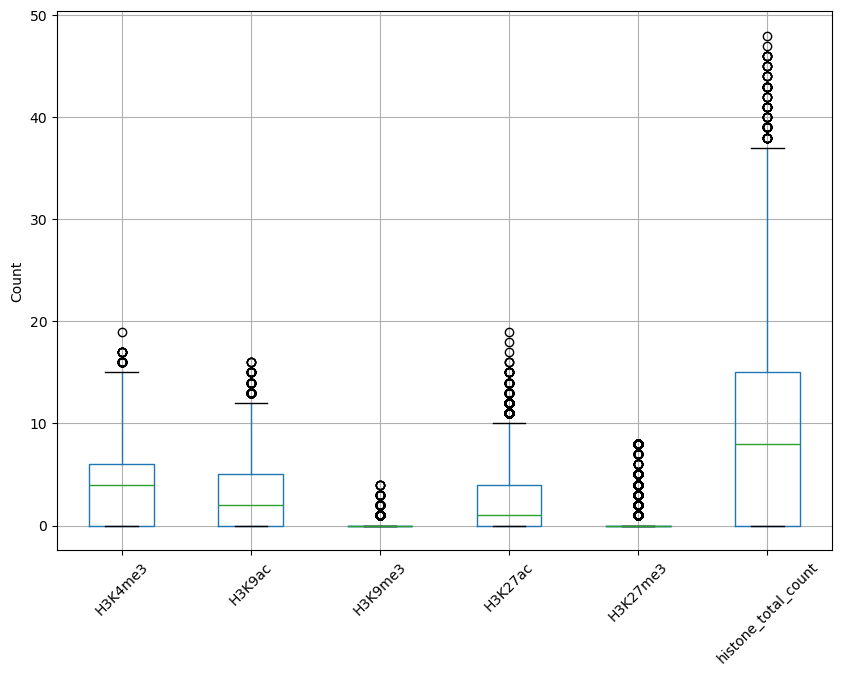

In [24]:
plt.figure(figsize=(10, 7))
ax = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count']].boxplot()
ax.set_ylabel("Count")
plt.xticks(rotation=45) 
plt.show()

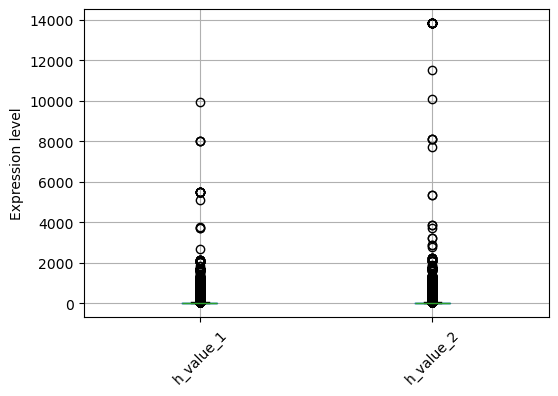

In [26]:
plt.figure(figsize=(6, 4))
ax = histone_count_df[['h_value_1', 'h_value_2']].boxplot()
ax.set_ylabel("Expression level")
plt.xticks(rotation=45)
plt.show()

## Plotting Each Feature vs value_1

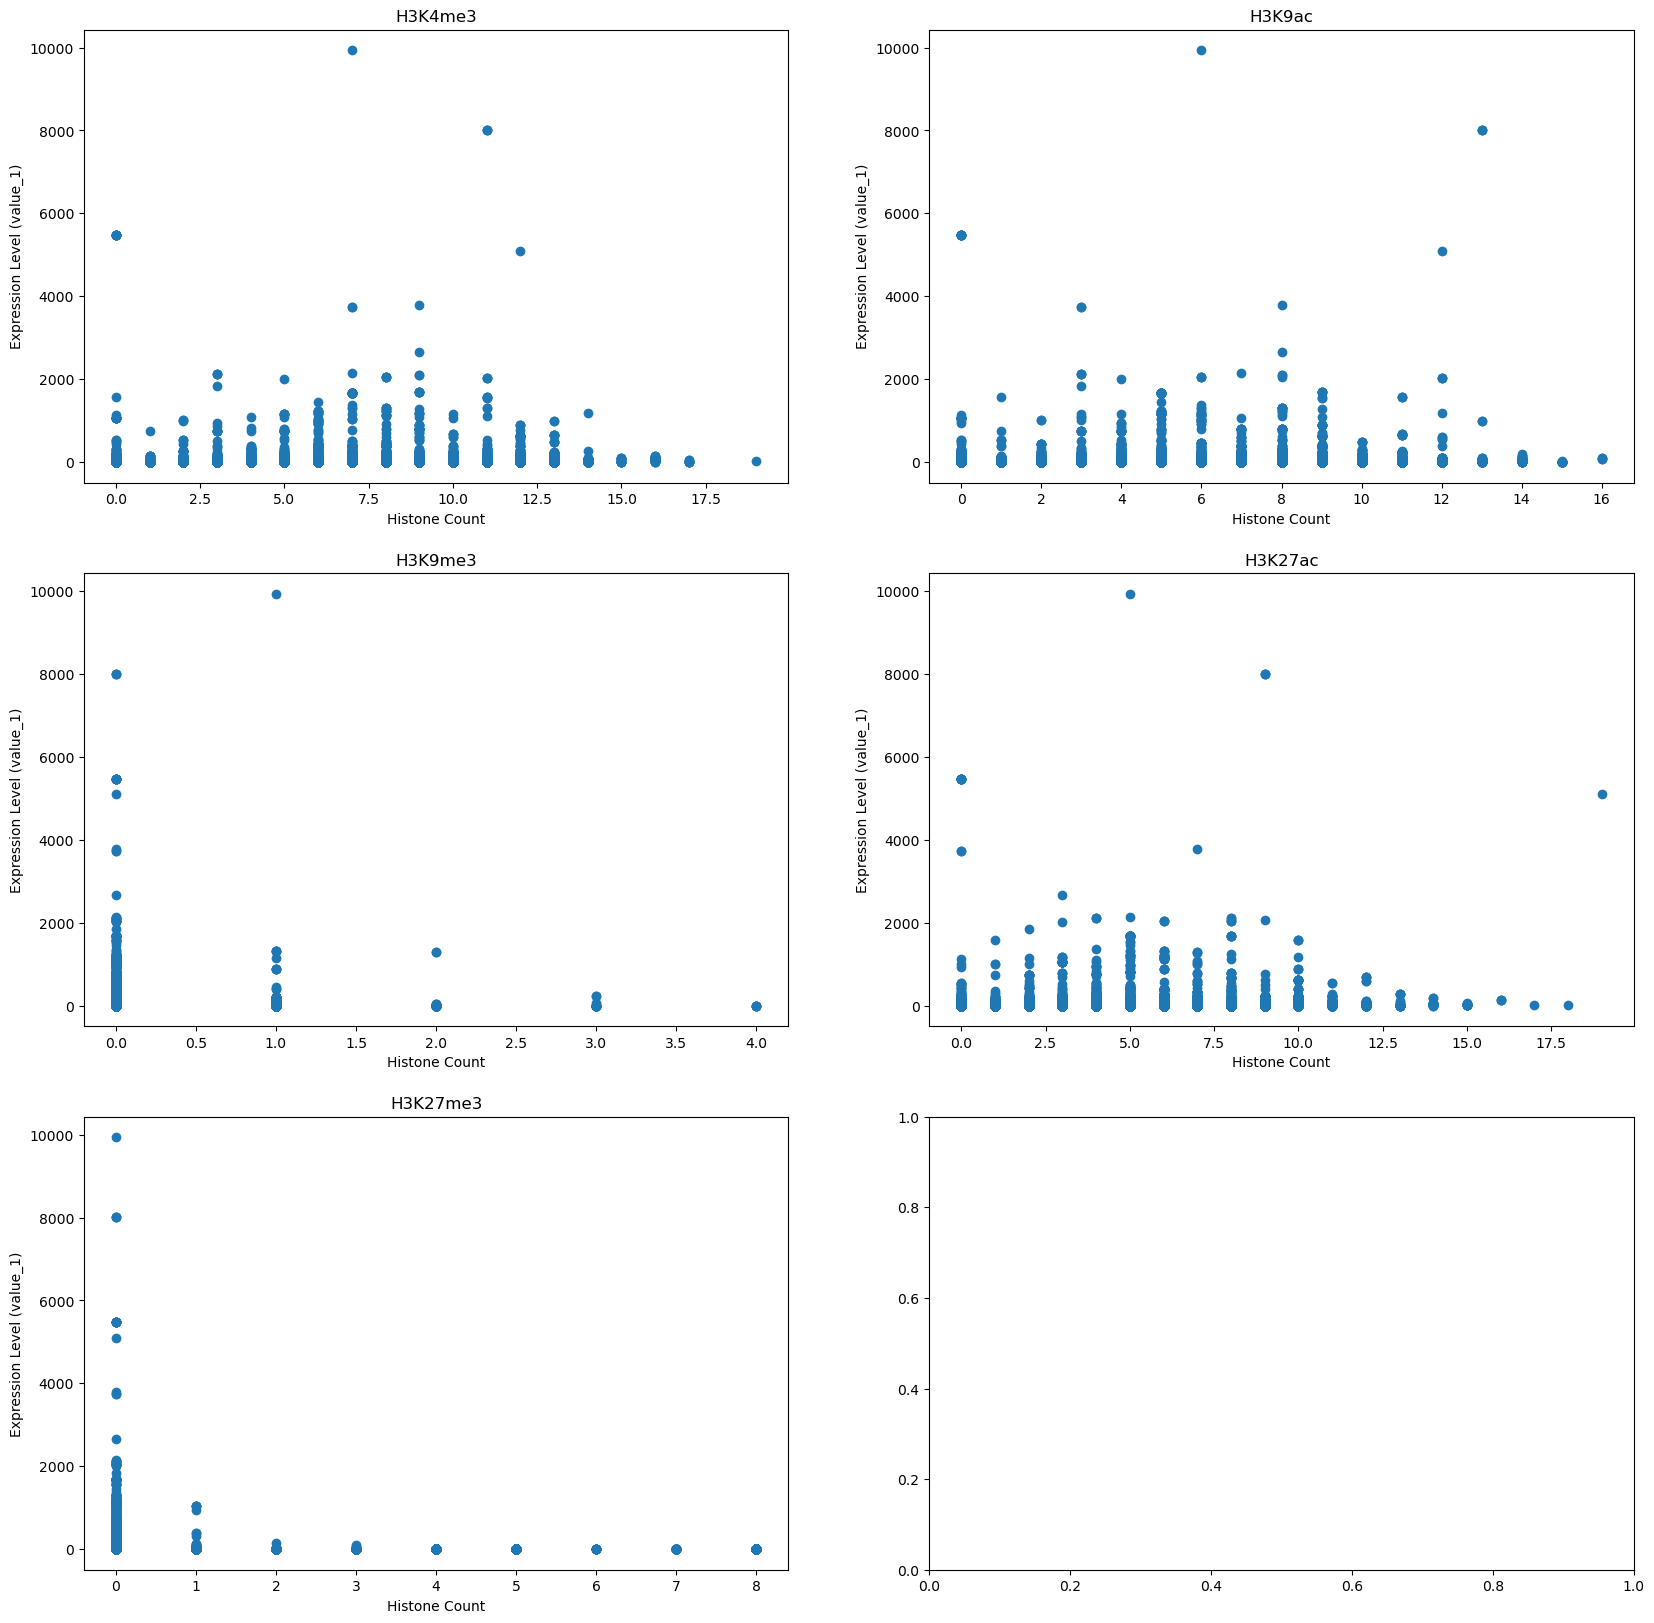

In [20]:
fig, axes = plt.subplots(nrows = 3, ncols=2, figsize = (20, 20))

# ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']
axes[0, 0].scatter(histone_count_df[['H3K4me3']], histone_count_df[['h_value_1']])
axes[0, 0].set_title("H3K4me3")
axes[0, 0].set_xlabel("Histone Count")
axes[0, 0].set_ylabel("Expression Level (value_1)")

axes[0, 1].scatter(histone_count_df[['H3K9ac']], histone_count_df[['h_value_1']])
axes[0, 1].set_title("H3K9ac")
axes[0, 1].set_xlabel("Histone Count")
axes[0, 1].set_ylabel("Expression Level (value_1)")


axes[1, 0].scatter(histone_count_df[['H3K9me3']], histone_count_df[['h_value_1']])
axes[1, 0].set_title("H3K9me3")
axes[1, 0].set_xlabel("Histone Count")
axes[1, 0].set_ylabel("Expression Level (value_1)")

axes[1, 1].scatter(histone_count_df[['H3K27ac']], histone_count_df[['h_value_1']])
axes[1, 1].set_title("H3K27ac")
axes[1, 1].set_xlabel("Histone Count")
axes[1, 1].set_ylabel("Expression Level (value_1)")

axes[2, 0].scatter(histone_count_df[['H3K27me3']], histone_count_df[['h_value_1']])
axes[2, 0].set_title("H3K27me3")
axes[2, 0].set_xlabel("Histone Count")
axes[2, 0].set_ylabel("Expression Level (value_1)")


plt.show()

# Pre-processing the Dataset

## Outlier Removal

In [ ]:
df = histone_count_df

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['h_value_1'].quantile(0.25)
Q3 = df['h_value_1'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound = {lower_bound}, upper bound = {upper_bound}")

# Filter out the outliers
histone_df_filtered = df[(df['h_value_1'] >= lower_bound) & (df['h_value_1'] <= upper_bound)]

# Display the filtered DataFrame
display(histone_df_filtered)
display(histone_df_filtered.shape)

In [ ]:
histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'h_value_1']].describe()

In [ ]:
plt.figure(figsize=(6, 4))
histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
histone_df_filtered[['h_value_1', 'h_value_2']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

## Scaling

In [ ]:
## To be implemented
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [ ]:
# Using original dataset
X = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y = histone_count_df[['h_value_1']]

In [ ]:
# Train, test, split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Transform the dataset
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

### Do another boxplot analysis

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(X_train_scaled)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(y_train_scaled)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

## Data with high gene expression and high total histone count

In [ ]:
high_gene_df = histone_count_df[(histone_count_df['h_value_1'] >= 1.02) & (histone_count_df['histone_total_count'] >= 8)]

display(high_gene_df.head())
display(high_gene_df.shape)

In [ ]:
display(high_gene_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count', 'h_value_1']].head(50))

In [ ]:
high_gene_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count', 'h_value_1']].describe()

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols=2, figsize = (20, 20))

# ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']
axes[0, 0].scatter(high_gene_df[['H3K4me3']], high_gene_df[['h_value_1']])
axes[0, 0].set_title("H3K4me3")
axes[0, 0].set_xlabel("Histone Count")
axes[0, 0].set_ylabel("Expression Level (value_1)")

axes[0, 1].scatter(high_gene_df[['H3K9ac']], high_gene_df[['h_value_1']])
axes[0, 1].set_title("H3K9ac")
axes[0, 1].set_xlabel("Histone Count")
axes[0, 1].set_ylabel("Expression Level (value_1)")

axes[1, 0].scatter(high_gene_df[['H3K9me3']], high_gene_df[['h_value_1']])
axes[1, 0].set_title("H3K9me3")
axes[1, 0].set_xlabel("Histone Count")
axes[1, 0].set_ylabel("Expression Level (value_1)")

axes[1, 1].scatter(high_gene_df[['H3K27ac']], high_gene_df[['h_value_1']])
axes[1, 1].set_title("H3K27ac")
axes[1, 1].set_xlabel("Histone Count")
axes[1, 1].set_ylabel("Expression Level (value_1)")

axes[2, 0].scatter(high_gene_df[['H3K27me3']], high_gene_df[['h_value_1']])
axes[2, 0].set_title("H3K27me3")
axes[2, 0].set_xlabel("Histone Count")
axes[2, 0].set_ylabel("Expression Level (value_1)")

plt.show()

In [ ]:
# Boxplot from the data
plt.figure(figsize=(10, 6))
ax = high_gene_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'histone_total_count']].boxplot()
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
ax = high_gene_df[['h_value_1']].boxplot()
ax.set_ylabel("Gene Expression Level")
plt.xticks(rotation=45)
plt.show()

# Modeling

## Original Dataset

In [27]:
# Using original dataset
X_orig = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y_orig = histone_count_df[['h_value_1']]

In [28]:
# Train, test, split
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)

In [29]:
print(len(X_orig_train))
print(len(X_orig_test))

47492
11874


### Simple Linear Regression

In [30]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_orig_train, y_orig_train)

# Make predictions on the test set
y_orig_pred = model.predict(X_orig_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_orig_test, y_orig_pred))

[22.551980246118575, 12499.820703977599, 111.80259703592577, 0.023939074145785777, inf, 9.392032568822325]


In [32]:
save_prediction(y_orig_test, y_orig_pred, "results/original_linear_regression.csv")

In [ ]:
model.coef_

### Polynomial Regression

In [35]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X_orig)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y_orig, test_size=0.2, random_state=42)

poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train, y_train)

y_predict = poly_reg_model.predict(X_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_test, y_predict))

save_prediction(y_test, y_predict, "results/original_polynomial_regression.csv")

[23.24530676402898, 12684.768133846665, 112.62667594245453, 0.00949727022655733, inf, 8.52341439460497]


In [ ]:
poly_reg_model.coef_

## Scaled Dataset

### Simple Linear Regression

In [ ]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_train_scaled, y_train_scaled)

# Make predictions on the test set
y_orig_pred = model.predict(X_test_scaled)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_orig_test, y_orig_pred))

## High Gene Expression and Histone Count Data

In [ ]:
# Using high gene dataset
X_high = high_gene_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y_high = high_gene_df[['h_value_1']]

display(len(X_high))
display(len(y_high))

In [ ]:
X_high.describe()

In [ ]:
y_high.describe()

In [ ]:
X_high_train, X_high_test, y_high_train, y_high_test = train_test_split(X_high, y_high, test_size=0.2, random_state=42)

print(f"Train: {len(X_high_train)}, Test: {len(X_high_test)}")

### Linear Regression

In [ ]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_high_train, y_high_train)

# Make predictions on the test set
y_high_predict = model.predict(X_high_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_high_test, y_high_predict))

In [ ]:
save_prediction(y_high_test, y_high_predict, "results/high_gene_linear_regression.csv")

### Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4, include_bias=False)

poly_features = poly.fit_transform(X_high)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y_high, test_size=0.2, random_state=42)

poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train, y_train)

y_predict = poly_reg_model.predict(X_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_test, y_predict))

save_prediction(y_test, y_predict, "results/high_gene_polynomial_regression.csv")

## Dataset without Outliers

In [ ]:
# Using dataset without outliers
X_filtered = histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y_filtered = histone_df_filtered[['h_value_1']]

# Train, test, split
X_filtered_train, X_filtered_test, y_filtered_train, y_filtered_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)


In [ ]:
print(len(X_filtered_train))
print(len(X_filtered_test))

### Simple Linear Regression

In [ ]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_filtered_train, y_filtered_train)

# Make predictions on the test set
y_filtered_pred = model.predict(X_filtered_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_filtered_test, y_filtered_pred))

In [ ]:
save_prediction(y_filtered_test, y_filtered_pred, "results/filtered_linear_regression.csv")